## ANOMALÍAS EN EQUIPOS INDUSTRIALES

ABSTRACT

Dentro de una industria es esencial realizar seguimiento de las variables. No solo de las que tienen incidencia en resultados financieros sino también en el desempeño de la producción. El área de de mantenimiento realiza mediciones recurrentes para evitar futuros prejuicios de los equipamentos e instalaciones y asi no comprometer la seguridad de los mismos y de las personas dentro del establecimiento.

El siguiente dataset ,obtenido desde la página de Kaggle, muestra un registro de variables fisicas (Presión, temperatura, vibración y humedad) en compresores, bombas y turbinas. Los equipos están ubicados en diferentes locaciones dentro de Estados Unidos.

El análisis se puede hacer extensivo para el todos los equipos industriales del dataset solo que, en este caso se buscará validar la incidencia de las variables físicas sobre la probabilidad de falla en turbinas.


HIPÓTESIS

Se buscará encontrar una relación entre las variables físicas y las veces que ocurrieron fallas en la Turbina. 
Se comprobará si alguna esas variables tiene más incidencia. Como por ejemplo, si valores altos de presión son la principal causa de fallas, o lo son las vibraciones.
Posteriormente, se desarrollará un modelo de predicción para saber si fallará o no frente a determinados valores de condiciones físicas, para asi reducir la necesidad de realizar mantenimiento correctivo y reducir la frecuencia de mantenimiento programado.

### ANÁLISIS DE DATASET

Se realiza un análisis exploratorio para saber cómo está conformado el dataset, seguido de un análisis estadístico donde se podrá detectar las primeras conclusiones.

In [1]:
import pandas as pd

# Cargar el archivo CSV principal
df = pd.read_csv("equipment_anomaly_data.csv")
print(df.head())

print(df.info())


   temperature   pressure  vibration   humidity   equipment       location  \
0    58.180180  25.029278   0.606516  45.694907     Turbine        Atlanta   
1    75.740712  22.954018   2.338095  41.867407  Compressor        Chicago   
2    71.358594  27.276830   1.389198  58.954409     Turbine  San Francisco   
3    71.616985  32.242921   1.770690  40.565138        Pump        Atlanta   
4    66.506832  45.197471   0.345398  43.253795        Pump       New York   

   faulty  
0     0.0  
1     0.0  
2     0.0  
3     0.0  
4     0.0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7672 entries, 0 to 7671
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   temperature  7672 non-null   float64
 1   pressure     7672 non-null   float64
 2   vibration    7672 non-null   float64
 3   humidity     7672 non-null   float64
 4   equipment    7672 non-null   object 
 5   location     7672 non-null   object 
 6   faulty      

ANÁLISIS ESTADÍSTICO

In [2]:
df_turbina = df[df['equipment'] == 'Turbine']
df_turbina.describe()

,temperature,pressure,vibration,humidity,faulty
count,2565.000000,2565.000000,2565.000000,2565.000000,2565.000000
mean,70.645348,35.855169,1.614488,49.675695,0.100585
std,16.251521,10.278006,0.741606,11.843054,0.300837
min,11.220335,5.165296,-0.428188,10.719373,0.000000
25%,62.465821,29.616814,1.174148,42.325967,0.000000
50%,69.758044,35.373099,1.528688,49.787272,0.000000
75%,77.158727,41.191017,1.924403,56.960423,0.000000
max,149.480406,79.887734,4.990537,89.984718,1.000000


In [3]:
# Crear lista de columnas de tabla informativa
columnas_tabla = [col for col in df_turbina.columns ]

# Crear un resumen con tipo de dato y cantidad de valores nulos
resumen = pd.DataFrame({
    'Tipo de dato': df_turbina[columnas_tabla].dtypes,
    'Valores nulos': df_turbina[columnas_tabla].isnull().sum(),
    'Porcentaje nulos (%)': df_turbina[columnas_tabla].isnull().mean() * 100
})

print(resumen)



            Tipo de dato  Valores nulos  Porcentaje nulos (%)
temperature      float64              0                   0.0
pressure         float64              0                   0.0
vibration        float64              0                   0.0
humidity         float64              0                   0.0
equipment         object              0                   0.0
location          object              0                   0.0
faulty           float64              0                   0.0


Según nos muestra este análisis, nuestras columnas no contienen valores nulos (NaN) . Adicionalmente nos muestra el tipo de datos con el que contamos en cada una de ellas.

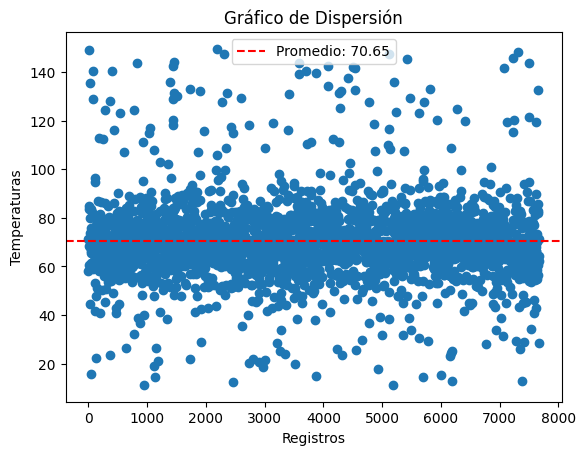

In [4]:
import matplotlib.pyplot as plt 
import numpy as np


x = df_turbina.index
y = df_turbina['temperature']
promedio_tempe= y.mean()

plt.scatter(x, y) 
plt.title('Gráfico de Dispersión') 
plt.xlabel('Registros') 
plt.axhline(promedio_tempe, color='red', linestyle='--', label=f'Promedio: {promedio_tempe:.2f}')
plt.ylabel('Temperaturas') 
plt.legend()
plt.show()

### DETECCIÓN Y FILTRADO DE OUTLIERS

C:\Users\victoria.palma\AppData\Local\Temp\ipykernel_14940\2404181116.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='equipment', y='temperature', data=df_turbina, palette='Set2')


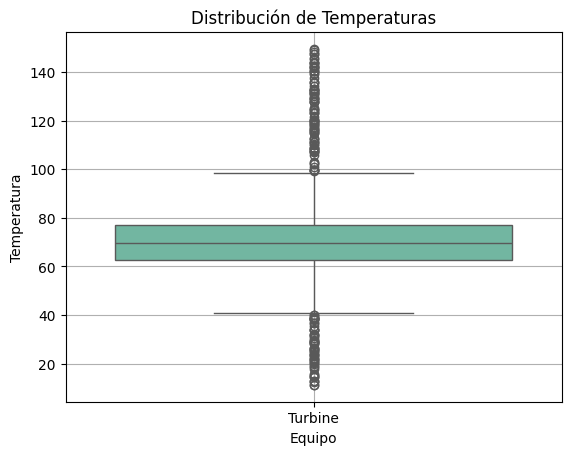

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# Crear boxplot
sns.boxplot(x='equipment', y='temperature', data=df_turbina, palette='Set2')

# Personalización
plt.title('Distribución de Temperaturas')
plt.xlabel('Equipo')
plt.ylabel('Temperatura')
plt.grid(True)

plt.show()


FILTRADO DE OUTLIERS: RANGO INTERCUARTIL

Para el entrenamiento del modelo, se precisa que el dataset no tenga outliers que puedan interferir en la predicción de las respuestas. Para ello, filtramos los valores outliers con la técnica estadística de rango intercuartílico.

In [6]:
#Calcular Q1 y Q3

Q1=df_turbina['temperature'].quantile(0.25)
Q3=df_turbina['temperature'].quantile(0.75)
IQR = Q3 - Q1

limiteinferior = Q1 - 1.5*IQR
limitesuperior = Q3 + 1.5*IQR

#filtrar para que quede sin outliers
sin_outliers = df_turbina[(df_turbina['temperature'] >= limiteinferior) & (df_turbina['temperature'] <= limitesuperior)]

print ("DF sin Outliers:")
print(sin_outliers)



# averiguamos qué porcentaje del total de nuestro dataset NO son outliers
total_datos = len(df_turbina)
total_sinoutliers = len(sin_outliers)

porcentaje_outliers = (total_sinoutliers / total_datos) * 100

print(f"Cantidad de datos filtrados (datos sin outliers): {total_sinoutliers:.2f}")
print(f"Porcentaje de datos sin outliers sobre el total de datos: {porcentaje_outliers:.2f}%")

DF sin Outliers:
      temperature   pressure  vibration   humidity equipment       location  \
0       58.180180  25.029278   0.606516  45.694907   Turbine        Atlanta   
2       71.358594  27.276830   1.389198  58.954409   Turbine  San Francisco   
13      84.711703  44.084965   1.359403  47.560971   Turbine  San Francisco   
14      83.736585  53.447573   1.643008  25.525049   Turbine       New York   
18      68.372071  21.394982   1.224774  47.377719   Turbine        Atlanta   
...           ...        ...        ...        ...       ...            ...   
7654    82.958718  33.590926   0.965781  55.287772   Turbine        Houston   
7658    56.518230  43.456472   0.844428  56.114135   Turbine  San Francisco   
7662    71.396537  27.255896   1.918917  65.060127   Turbine        Houston   
7663    64.259174  32.131660   1.874060  39.069232   Turbine       New York   
7665    62.179965  36.422638   1.565271  51.606218   Turbine        Atlanta   

      faulty  
0        0.0  
2   

### IDENTIFICAR CARACTERÍSTICAS RELEVANTES

Se debe identificar las variables físicas que más impactan en la variable "faulty" (falla/no falla) para luego entrenar el modelo de predicción en base a ellas.

             temperature  pressure  vibration  humidity    faulty
temperature     1.000000  0.007042   0.021701 -0.054190  0.017392
pressure        0.007042  1.000000   0.030267 -0.018260  0.127263
vibration       0.021701  0.030267   1.000000  0.025531  0.345725
humidity       -0.054190 -0.018260   0.025531  1.000000 -0.004729
faulty          0.017392  0.127263   0.345725 -0.004729  1.000000


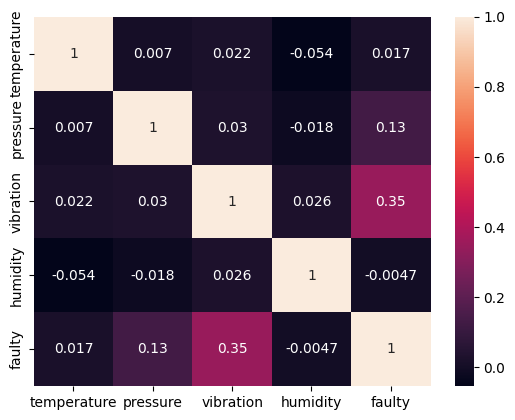

In [7]:
df_sin_equipment= sin_outliers.drop(columns=['equipment' , 'location'])
correlation_matrix= df_sin_equipment.corr()
print(correlation_matrix)
import seaborn as sns
sns.heatmap(correlation_matrix, annot=True)
plt.show()

Como podemos observar en la matriz de correlación las variables que más influyen sobre el campo falla son : vibración, presión y temperatura. Esto también lo validaremos posteriormente con el método f_classifier.

In [8]:
print(df_turbina.columns) # A modo informativo, se detectan las columnas de nuestro dataset de turbina


Index(['temperature', 'pressure', 'vibration', 'humidity', 'equipment',
       'location', 'faulty'],
      dtype='object')


In [9]:
import seaborn as sns
from sklearn.feature_selection import SelectKBest, f_classif

# 1. Definir X (solo columnas numéricas) e y
columnas_numericas = ['temperature', 'pressure', 'vibration', 'humidity']
X_car = df_turbina[columnas_numericas]
y_car = df_turbina['faulty']

# 2. Aplicar SelectKBest con f_classif
k = 3  # Número de características a seleccionar
selector = SelectKBest(score_func=f_classif, k=k)
X_seleccionado = selector.fit_transform(X_car, y_car)

# 3. Obtener nombres de características seleccionadas
caracteristicas_seleccionadas = X_car.columns[selector.get_support()].tolist()

# 4. Mostrar resultados
print("\nCaracterísticas seleccionadas:")
for caracteristica in caracteristicas_seleccionadas:
    print(f"- {caracteristica}")



Características seleccionadas:
- temperature
- pressure
- vibration


Se corrobora que las 3 variables físicas de interés,son las que se mencionaban en la matriz de correlación

### CREACIÓN DEL MODELO DE PREDICCIÓN

Se evaluará si el modelo de predicción de regresión logística o random forest se ajusta mejor. Ambos son modelos de aprendizaje supervisado.

REGRESIÓN LOGÍSTICA

Métricas del modelo de Regresión Logística:
Accuracy       : 0.9474
Precision      : 0.9615
Recall         : 0.4902
F1-score       : 0.6494


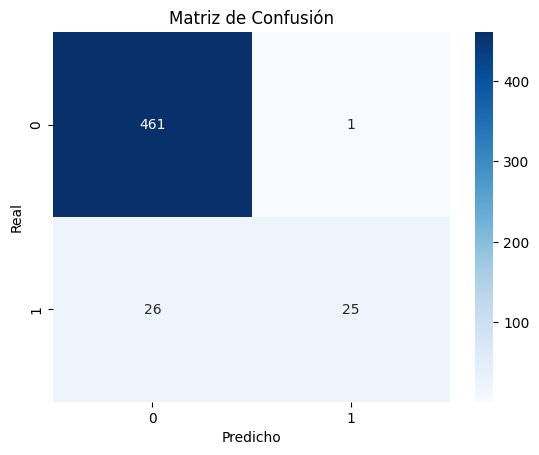

Classification Report:
              precision    recall  f1-score   support

         0.0       0.95      1.00      0.97       462
         1.0       0.96      0.49      0.65        51

    accuracy                           0.95       513
   macro avg       0.95      0.74      0.81       513
weighted avg       0.95      0.95      0.94       513



In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Dividir en train/test
X_train, X_test, y_train, y_test = train_test_split(X_car, y_car, test_size=0.2, random_state=42)

# Entrenar modelo de regresión logística
modelo = LogisticRegression(max_iter=1000)
modelo.fit(X_train, y_train)

# Predecir
y_pred = modelo.predict(X_test)

# Calcular métricas
print("Métricas del modelo de Regresión Logística:")
print(f"Accuracy       : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision      : {precision_score(y_test, y_pred):.4f}")
print(f"Recall         : {recall_score(y_test, y_pred):.4f}")
print(f"F1-score       : {f1_score(y_test, y_pred):.4f}")

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de Confusión")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.show()

# Reporte completo
print("Classification Report:")
print(classification_report(y_test, y_pred))


RANDOM FOREST

Métricas para Random Forest:
Accuracy : 0.9786
Precision: 0.9167
Recall   : 0.8627
F1-score : 0.8889


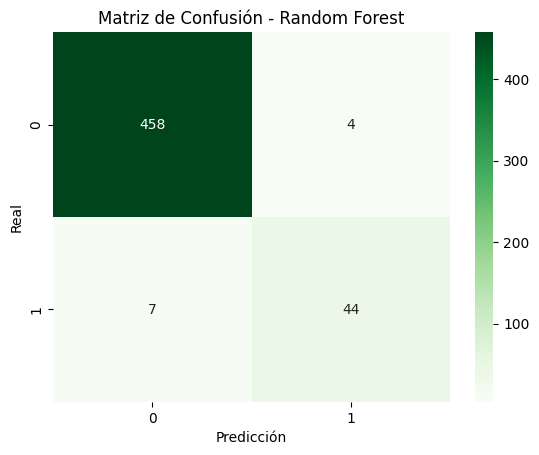

Reporte de clasificación:
              precision    recall  f1-score   support

         0.0       0.98      0.99      0.99       462
         1.0       0.92      0.86      0.89        51

    accuracy                           0.98       513
   macro avg       0.95      0.93      0.94       513
weighted avg       0.98      0.98      0.98       513



In [11]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt


# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_car, y_car, test_size=0.2, random_state=42)

# Entrenar Random Forest
modelo = RandomForestClassifier(random_state=42)
modelo.fit(X_train, y_train)

# Predecir
y_pred = modelo.predict(X_test)

# Métricas
print("Métricas para Random Forest:")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred):.4f}")

# Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("Matriz de Confusión - Random Forest")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

# Reporte completo
print("Reporte de clasificación:")
print(classification_report(y_test, y_pred))

RESUMEN COMPARANDO AMBOS MÉTODOS

El modelo de random forest es el que mejor se adapta a nuestra dataset. Tiene un Accuracy de 0.98 contra 0.95 de regresión logística.

| Métrica                 | Qué mide?                                                     |  Random Forest          |   Regresión Logística  |   
| ----------------------- | ------------------------------------------------------------- |------------------------ |------------------------|
| **Accuracy**            | Proporción de predicciones correctas                          |  0.9786                   |    0.9474                    |   
| **Precision**           | ¿Qué tan confiable es el modelo cuando dice “positivo”? |  0.9167              | 0.9615                        |   
| **Recall**              | ¿Qué tan bien encuentra el modelo los positivos reales?                  |  0.8627              |   0.4902                     |   
| **F1-score**            | Balance entre precisión y recall                              |  0.8889              |   0.6494                     |   


## INCLUSIÓN DE API

Integraremos a nuestro modelo una API meteorológica. Se buscará encontrar la probabilidad de falla de la turbina y la temperatura ambiente de la localidad de Atlanta para el mes de Octubre de 2025.

In [12]:
df_turbina2 = sin_outliers[sin_outliers['equipment'] == 'Turbine']
df_turbina2.describe()
conteo_dfturbina2 = df_turbina2.groupby('location').size().reset_index(name='Cantidad')
print(conteo_dfturbina2)
print(df_turbina2.head())

        location  Cantidad
0        Atlanta       502
1        Chicago       469
2        Houston       499
3       New York       479
4  San Francisco       454
    temperature   pressure  vibration   humidity equipment       location  \
0     58.180180  25.029278   0.606516  45.694907   Turbine        Atlanta   
2     71.358594  27.276830   1.389198  58.954409   Turbine  San Francisco   
13    84.711703  44.084965   1.359403  47.560971   Turbine  San Francisco   
14    83.736585  53.447573   1.643008  25.525049   Turbine       New York   
18    68.372071  21.394982   1.224774  47.377719   Turbine        Atlanta   

    faulty  
0      0.0  
2      0.0  
13     0.0  
14     0.0  
18     0.0  


In [13]:
#Treaemos nuevamente el dataframe con los valores filtrados para el equipo Turbina, filtrando los datos solo para Atlanta
df_turbina_atlanta = sin_outliers[(sin_outliers['equipment'] == 'Turbine') & (sin_outliers['location'] == 'Atlanta')]
print(df_turbina_atlanta .head())

conteo_dfturbina_atlanta = df_turbina_atlanta.groupby('faulty').size().reset_index(name='Cantidad')
print(conteo_dfturbina_atlanta)

    temperature   pressure  vibration   humidity equipment location  faulty
0     58.180180  25.029278   0.606516  45.694907   Turbine  Atlanta     0.0
18    68.372071  21.394982   1.224774  47.377719   Turbine  Atlanta     0.0
44    69.016902  53.664284   1.380225  70.495073   Turbine  Atlanta     0.0
49    83.641404  25.740674   1.257435  42.644693   Turbine  Atlanta     0.0
51    61.255644  32.126947   1.987554  58.671531   Turbine  Atlanta     0.0
   faulty  Cantidad
0     0.0       483
1     1.0        19


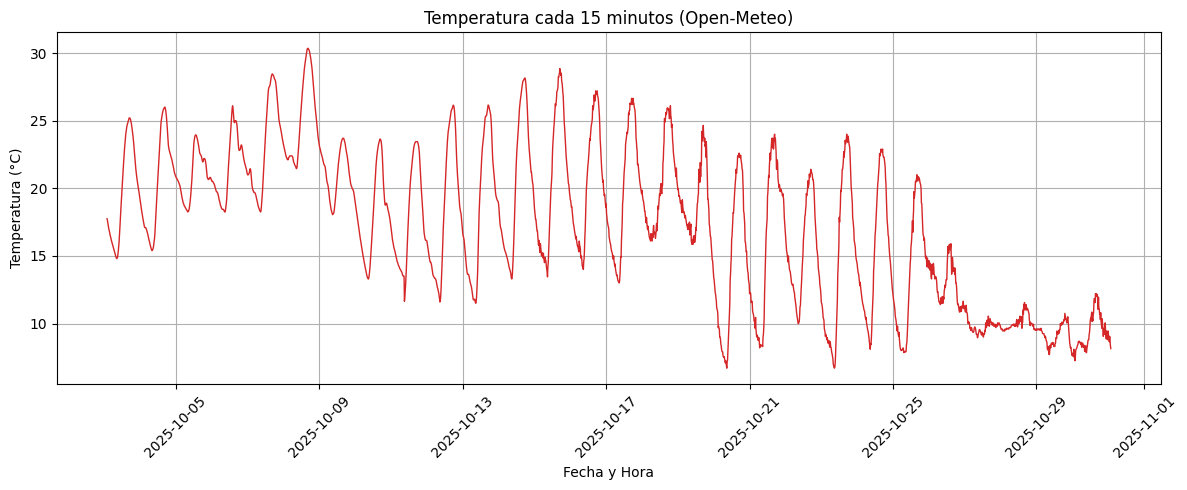

In [20]:
#Incluimos la API desde Open Meteo
import openmeteo_requests
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime, timedelta

# Crear cliente
openmeteo = openmeteo_requests.Client()

# Parámetros de la API
url = "https://api.open-meteo.com/v1/forecast"
params = {
    "latitude": 33.7490,
    "longitude": -84.3880,
    "minutely_15": ["temperature_2m"],
    "start_date": "2025-10-03",
    "end_date": "2025-10-30",
    "timezone": "America/New_York"
}

# Llamada a la API
responses = openmeteo.weather_api(url, params=params)
response = responses[0]

# Extraer datos cada 15 minutos
minutely = response.Minutely15()

# Valores de temperatura
temperaturas = minutely.Variables(0).ValuesAsNumpy()

# Tiempo inicial
start_time = datetime.fromtimestamp(minutely.Time())

# Intervalo (900 segundos = 15 min)
interval = minutely.Interval()

# Generar fechas
fechas = [start_time + timedelta(seconds=i * interval)
          for i in range(len(temperaturas))]

# Crear DataFrame
df_temp = pd.DataFrame({
    "Fecha_Hora": fechas,
    "Temperatura_API": temperaturas
})

# Gráfico
plt.figure(figsize=(12, 5))
plt.plot(df_temp["Fecha_Hora"], df_temp["Temperatura_API"],
         color="tab:red", linewidth=1)

plt.xlabel("Fecha y Hora")
plt.ylabel("Temperatura (°C)")
plt.title("Temperatura cada 15 minutos (Open-Meteo)")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Como nuestro dataset de Turbina no cuenta con una columna de fecha y hora correspondiente al momento de la toma de muestras, se consultó con la gerencia de mantenimiento y nos informaron que las muestras se toman cada 15 minutos durante Octubre del 2025. Por ello, iniciaremos el proceso de ajuste del nuevo dataset con fechas

In [21]:
# Agregamos una columna de fechas y hora al dataframe de Turbina, para unirlo con el dataframe con la API
start_time = df_temp["Fecha_Hora"].iloc[0]

df_turbina_atlanta = df_turbina_atlanta.reset_index(drop=True)
df_turbina_atlanta["Fecha_Hora"] = pd.date_range(
    start=start_time,
    periods=len(df_turbina_atlanta),
    freq="15min"  # AJUSTA si no es 15min
)


In [22]:
#unimos el dataframe de fechas con la API con el de la turbina
df_merged = pd.merge(
    df_turbina_atlanta,
    df_temp[["Fecha_Hora", "Temperatura_API"]],
    on="Fecha_Hora",
    how="inner"
)

#df_merged.to_csv("checkit2.csv")

Una vez confeccionado nuestro nuevo dataframe, debemos analizar las variables más relevantes. Como podremos ver, la temperatura ambiente (Temperatura_ API) no influencia en la probabilidad de fallo del equipo. Sin embargo, si lo hacen las vibraciones mecánicas, la presión y la temperatura a la que trabaja el equipo (temperature), como ya habíamos corroborado anteriormente.

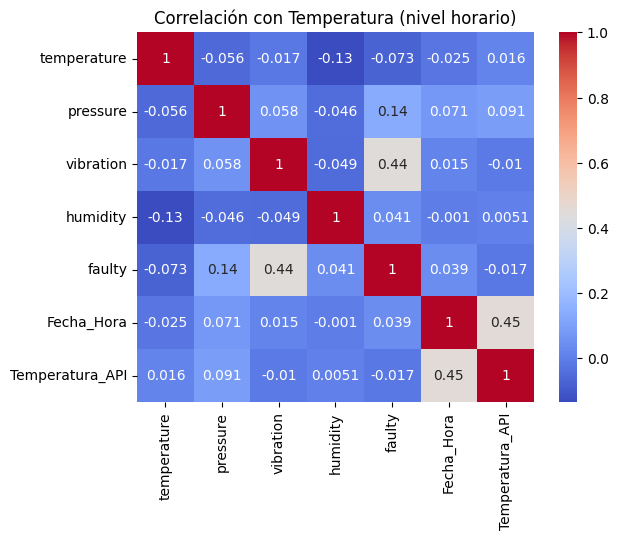

In [23]:
df_corr = df_merged.drop(columns=["equipment", "location"], errors="ignore")
correlation_matrix = df_corr.corr()

sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")
plt.title("Correlación con Temperatura (nivel horario)")
plt.show()


In [24]:
df_corr.head()

,temperature,pressure,vibration,humidity,faulty,Fecha_Hora,Temperatura_API
0,58.180180,25.029278,0.606516,45.694907,0.0,2025-10-03 02:00:00,17.750000
1,68.372071,21.394982,1.224774,47.377719,0.0,2025-10-03 02:15:00,17.600000
2,69.016902,53.664284,1.380225,70.495073,0.0,2025-10-03 02:30:00,17.450001
3,83.641404,25.740674,1.257435,42.644693,0.0,2025-10-03 02:45:00,17.250000
4,61.255644,32.126947,1.987554,58.671531,0.0,2025-10-03 03:00:00,17.100000


Corroboramos las características relevantes

In [25]:
import seaborn as sns
from sklearn.feature_selection import SelectKBest, f_classif

# 1. Definir X (solo columnas numéricas) e y
columnas_numericas2 = ['temperature', 'pressure', 'vibration', 'humidity','Temperatura_API']
X_car2 = df_corr[columnas_numericas2]
y_car2 = df_corr['faulty']

# 2. Aplicar SelectKBest con f_classif
k = 3  # Número de características a seleccionar
selector = SelectKBest(score_func=f_classif, k=k)
X_seleccionado = selector.fit_transform(X_car2, y_car2)

# 3. Obtener nombres de características seleccionadas
caracteristicas_seleccionadas = X_car2.columns[selector.get_support()].tolist()

# 4. Mostrar resultados
print("\nCaracterísticas seleccionadas:")
for caracteristica in caracteristicas_seleccionadas:
    print(f"- {caracteristica}")



Características seleccionadas:
- temperature
- pressure
- vibration


Como en el ejercicio previo a incluir la API el mejor algoritmo que se ajustaba fué Random Forest , entrenaremos nuestro nuevo dataframe con este mismo algoritmo.

Métricas para Random Forest:
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-score : 1.0000


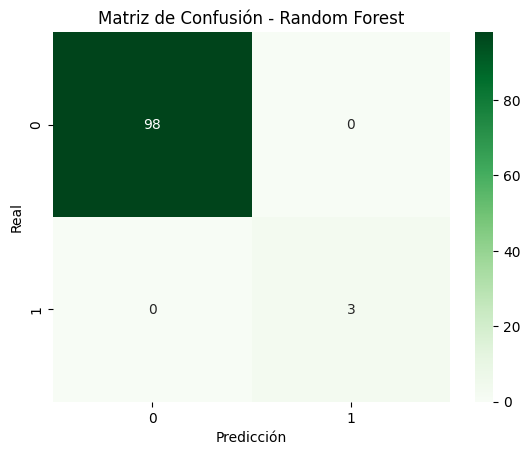

Reporte de clasificación:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        98
         1.0       1.00      1.00      1.00         3

    accuracy                           1.00       101
   macro avg       1.00      1.00      1.00       101
weighted avg       1.00      1.00      1.00       101



In [26]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt


# Dividir en entrenamiento y prueba
X_train2, X_test2, y_train2, y_test2 = train_test_split(X_car2, y_car2, test_size=0.2, random_state=42)

# Entrenar Random Forest
modelo2 = RandomForestClassifier(random_state=42)
modelo2.fit(X_train2, y_train2)

# Predecir
y_pred2 = modelo2.predict(X_test2)

# Métricas
print("Métricas para Random Forest:")
print(f"Accuracy : {accuracy_score(y_test2, y_pred2):.4f}")
print(f"Precision: {precision_score(y_test2, y_pred2):.4f}")
print(f"Recall   : {recall_score(y_test2, y_pred2):.4f}")
print(f"F1-score : {f1_score(y_test2, y_pred2):.4f}")

# Matriz de Confusión
cm2 = confusion_matrix(y_test2, y_pred2)
sns.heatmap(cm2, annot=True, fmt='d', cmap='Greens')
plt.title("Matriz de Confusión - Random Forest")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

# Reporte completo
print("Reporte de clasificación:")
print(classification_report(y_test2, y_pred2))

Los resultados obtenidos nos hacen sospechar de estar frente a un caso de overfitting. Por lo que optimizaremos nuestro modelo de Random Forest con GridSeachCV

# Optimización con Hiperparámetros (GridSearchCV)

Es un método caro computacionalmente ya que explora todos los parámetros. Sin embargo, ya que nuestro dataset es relativamente pequeño se decidió usar este método para tener mejores resultados.
Definimos una grilla de hiperparámetros y el modelo seleccionará la mejor combinación de hiperparámetros que mejor optimicen el modelo

In [27]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Modelo base
modelo = RandomForestClassifier(random_state=42)

# Grilla de hiperparámetros
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

# GridSearch
grid = GridSearchCV(
    estimator=modelo,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Entrenamiento
grid.fit(X_train, y_train)

# Mejores resultados
print("Mejores hiperparámetros:", grid.best_params_)
print("Mejor score:", grid.best_score_)

# Mejor modelo ya entrenado
best_model = grid.best_estimator_


Mejores hiperparámetros: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
Mejor score: 0.9844080470001781


A continuación interpretaremos los resultados obtenidos.

-n_estimators:200. El modelo determinó usar la mayor cantidad de árboles en el bosque, por lo que lo hará más estable.

-max_depth: 10. Describe la profundidad máxima de los árboles. Árboles muy profundos (complejos) pueden hacer que el modelo tenga overfitting

-min_samples_split: 2. Número mínimo de muestras para dividir un nodo. El modelo seleccinó el mínimo que definimos en la grilla, por lo que siempre que tenga oportunidad de dividir, lo hará.


In [28]:
from sklearn.metrics import accuracy_score

y_pred = best_model.predict(X_test)
accuracy_test = accuracy_score(y_test, y_pred)
print("Accuracy en test:", accuracy_test)


Accuracy en test: 0.9785575048732943


Como podemos observar la evaluación de accuracy en el conjunto de test es menor que el Mejor Score
accuracy en test= 0.979
best_score = 0.984 
Al ser menor a 0.02 la diferencia, podemos asegurar que no hay overffiting en nuestro modelo



In [ ]:
#import joblib
#joblib.dump(best_model, "modelo_rf.pkl")
#para lanzar a producción


# Conclusiones Finales

En primer instancia recordemos nuestra hipótesis.

*Se comprobará si alguna de las variables tiene más incidencia en los eventos de fallas*

La matriz de correlación lanzó que las 3 principales variables que influyen en la probabilidad de fallo de la turbina son.

-Vibraciones

-Presión

-Temperatura de trabajo del equipo

Esto se condice con los principios de mecánica de equipamientos industriales. 
Altos valores de vibraciones hace que haya fricción entre partes estáticas y rotativas, disminuyendo la vida útil de acoplamientos, cojinetes, etc e induciendo finalmente el fallo de la turbina.

Valores de presión fuera de lo recomendado por el fabricante pueden hacer que el vapor que ingresa a la turbina (en caso que sea una turbina de vapor) condense generándose asi pequeñas microgotas. Las mismas al chocar contra los álabes de la turbina que giran a grandes rpm funcionan como granos de arena que los erosionan, conduciendo asi al fallo. De igual manera influye la temperatura a la que trabaja el equipo, esta variable también afecta en la calidad del vapor utilizado.

Una vez entendido en problema y como se relacionan las variables, creamos un modelo de machine learning  con RandomForest que prediga la probabilidad de fallo de la turbina según ciertos valores de las variables físicas críticas que la matriz de correlación arrojó.
Para hacer aún más robosto nuestro modelo, lo optimizamos por hiperparámetros con GridSearchCV (cross-validation). Esto permitirá que una vez que esté en producción, las predicciones sean confiables ante la presencia de nuevos datos. 